# Qué hace el greedy en grande: intuición visual

El greedy corre a escala (n=50 en segundos con la variante gibbs o secuencial).
La pregunta de este notebook no es *si* corre, sino **qué hace** cuando corre, y
por qué. Lo vemos sobre una instancia grande (n=40), trazando cada test y
visualizando cómo el greedy limpia a la población.

La regla, recordada en una línea: en cada paso elige el pool que maximiza la
utilidad limpiada inmediata,

$$\text{Score}(t) = \Big(\textstyle\prod_{i\in t}(1-\tilde p_i)\Big)\sum_{i\in t} u_i,$$

es decir, **probabilidad de que el pool salga limpio** por **utilidad que cobraría
si sale limpio**. Todo lo demás se sigue de esa tensión.

In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from augmented.core import (indices_from_mask, mask_from_indices, test_result,
                            compute_active_mask)
from augmented.greedy import _myopic_best_pool
from augmented.bayesian import bayesian_update_single_test
print('listo')

listo


## 1. La regla, en un ejemplo chico

Antes del caso grande, la tensión en miniatura. Entre dos pools candidatos, el
greedy no elige solo por utilidad ni solo por seguridad, sino por el producto.

In [2]:
# Cuatro personas con (prob de infección, utilidad)
p_demo = [0.02, 0.30, 0.05, 0.04]
u_demo = [1.0,  3.0,  2.0,  2.0]
cands = [[0,2,3], [1,2,3], [0,2], [1]]
print(f"{'pool':>10} {'P(limpio)':>10} {'Σ utilidad':>11} {'Score':>8}")
for t in cands:
    pc = np.prod([1-p_demo[i] for i in t]); su = sum(u_demo[i] for i in t)
    print(f"{str(t):>10} {pc:>10.3f} {su:>11.1f} {pc*su:>8.3f}")
print("\\nLa persona 1 tiene la utilidad más alta (3) pero también el riesgo más")
print("alto (0.30): meterla baja la P(limpio) y casi nunca cobra. El greedy")
print("prefiere el pool de gente segura aunque su utilidad sea algo menor.")

      pool  P(limpio)  Σ utilidad    Score
 [0, 2, 3]      0.894         5.0    4.469
 [1, 2, 3]      0.638         7.0    4.469
    [0, 2]      0.931         3.0    2.793
       [1]      0.700         3.0    2.100
\nLa persona 1 tiene la utilidad más alta (3) pero también el riesgo más
alto (0.30): meterla baja la P(limpio) y casi nunca cobra. El greedy
prefiere el pool de gente segura aunque su utilidad sea algo menor.


## 2. El greedy en vivo sobre una instancia grande (n=40)

Generamos 40 personas con riesgos bajos-moderados y utilidades en {1,2,3},
sorteamos quién está infectado de verdad, y corremos el greedy con presupuesto
B=12 y pools de hasta G=5. Trazamos cada test: qué pool eligió, el conteo
observado, y a quién limpió.

In [3]:
rng = np.random.default_rng(7)
n, B, G = 40, 12, 5
p = rng.uniform(0.02, 0.18, size=n).tolist()
u = rng.choice([1., 2., 3.], size=n).tolist()
z_mask = 0
for i in range(n):
    if rng.random() < p[i]:
        z_mask |= (1 << i)
print(f"n={n}, B={B}, G={G} | infectados reales: {bin(z_mask).count('1')} de {n}")

def trace_greedy(p, u, B, G, z_mask):
    n = len(p)
    cur = list(p); cleared = set(); cleared_mask = 0
    status = np.zeros((n, B + 1), dtype=int)        # 0=incierto,1=limpio,2=deducido infectado
    steps = []
    for b in range(B):
        pool = _myopic_best_pool(cur, u, G, n, cleared_mask)
        if pool == 0:
            status[:, b + 1:] = status[:, b][:, None]; break
        members = indices_from_mask(pool, n)
        r = test_result(pool, z_mask)
        newly = []
        if r == 0:
            cleared_mask |= pool
            newly = [i for i in members if i not in cleared]
            cleared |= set(members)
        cur = bayesian_update_single_test(cur, pool, r, n)
        for i in range(n):
            status[i, b + 1] = 1 if i in cleared else (2 if cur[i] > 0.999 else 0)
        steps.append(dict(b=b + 1, pool=members, r=r, newly=newly,
                          util=sum(u[i] for i in cleared), ncleared=len(cleared)))
    return steps, status, cleared

steps, status, cleared = trace_greedy(p, u, B, G, z_mask)
for s in steps[:6]:
    miembros = ', '.join(f'{i}(p={p[i]:.02f},u={int(u[i])})' for i in s['pool'])
    res = 'LIMPIO' if s['r'] == 0 else f"r={s['r']} (positivo)"
    print(f"test {s['b']:>2}: pool [{miembros}] -> {res}"
          f"{'  limpia ' + str(s['newly']) if s['newly'] else ''}")
print(f"\\n... tras {len(steps)} tests: {len(cleared)} personas limpias, "
      f"utilidad cobrada = {steps[-1]['util']:.1f}")

n=40, B=12, G=5 | infectados reales: 5 de 40


test  1: pool [3(p=0.06,u=3), 6(p=0.02,u=3), 20(p=0.05,u=3), 33(p=0.05,u=3), 37(p=0.02,u=3)] -> LIMPIO  limpia [3, 6, 20, 33, 37]
test  2: pool [11(p=0.06,u=3), 21(p=0.05,u=2), 23(p=0.03,u=2), 32(p=0.02,u=2), 39(p=0.04,u=2)] -> LIMPIO  limpia [11, 21, 23, 32, 39]
test  3: pool [2(p=0.14,u=3), 8(p=0.15,u=3), 12(p=0.06,u=2), 35(p=0.05,u=2), 36(p=0.08,u=2)] -> r=1 (positivo)
test  4: pool [7(p=0.15,u=3), 9(p=0.09,u=2), 19(p=0.18,u=3), 26(p=0.09,u=2), 35(p=0.05,u=2)] -> r=2 (positivo)
test  5: pool [12(p=0.06,u=2), 15(p=0.11,u=2), 16(p=0.18,u=3), 22(p=0.12,u=2), 24(p=0.03,u=1)] -> LIMPIO  limpia [12, 15, 16, 22, 24]
test  6: pool [0(p=0.12,u=2), 17(p=0.15,u=2), 18(p=0.12,u=2), 28(p=0.12,u=2), 34(p=0.13,u=2)] -> LIMPIO  limpia [0, 17, 18, 28, 34]
\n... tras 12 tests: 28 personas limpias, utilidad cobrada = 58.0


## 3. Visualización 1 — el mapa de limpieza

Cada fila es una persona (ordenadas por riesgo prior, de menor a mayor hacia
arriba); cada columna es un test. Verde = ya limpia, gris = incierta, rojo =
deducida infectada. Se ve el patrón central: **el greedy limpia primero a la gente
de bajo riesgo** (las filas de abajo se ponen verdes temprano) y va subiendo hacia
los riesgos altos solo si el presupuesto alcanza.

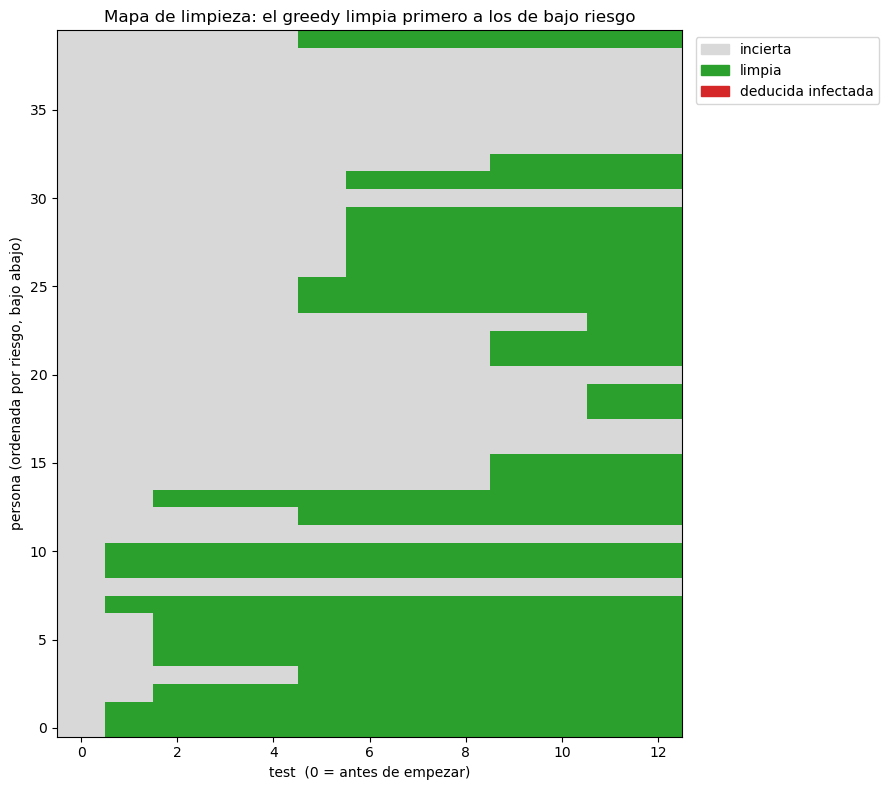

In [4]:
order = np.argsort(p)                  # bajo riesgo abajo
S = status[order, :]
cmap = ListedColormap(['0.85', 'tab:green', 'tab:red'])
fig, ax = plt.subplots(figsize=(9, 8))
ax.imshow(S, aspect='auto', cmap=cmap, vmin=0, vmax=2, origin='lower',
          interpolation='nearest')
ax.set_xlabel('test  (0 = antes de empezar)'); ax.set_ylabel('persona (ordenada por riesgo, bajo abajo)')
ax.set_title('Mapa de limpieza: el greedy limpia primero a los de bajo riesgo')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='0.85', label='incierta'),
                   Patch(color='tab:green', label='limpia'),
                   Patch(color='tab:red', label='deducida infectada')],
          loc='upper left', bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.show()

## 4. Visualización 2 — la curva de ganancia

La utilidad cobrada acumulada contra el número de tests. Sube rápido al principio
—los primeros pools, sobre gente segura, casi siempre salen limpios y cobran
mucho— y se aplana después, cuando solo quedan personas de mayor riesgo y los pools
empiezan a salir positivos. Es la firma de una heurística miope: cosecha lo fácil
primero.

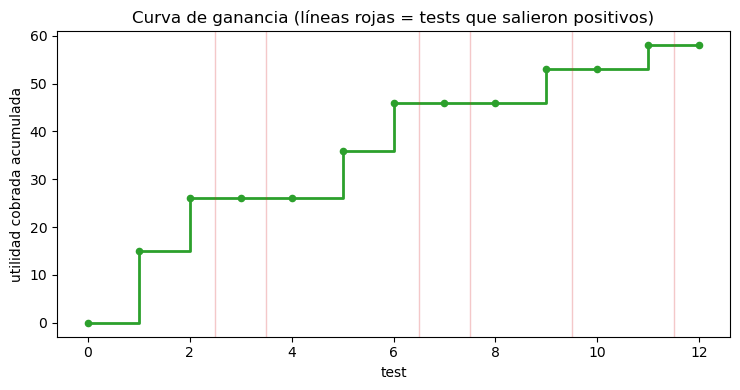

Rendimiento decreciente: los tests positivos (rojo) aparecen más tarde,
cuando ya solo queda gente de mayor riesgo.


In [5]:
xs = [0] + [s['b'] for s in steps]
ys = [0] + [s['util'] for s in steps]
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.step(xs, ys, where='post', color='tab:green', lw=2)
ax.scatter(xs, ys, color='tab:green', s=20)
for s in steps:
    if s['r'] != 0:
        ax.axvline(s['b'] - 0.5, color='tab:red', alpha=0.25, lw=1)
ax.set_xlabel('test'); ax.set_ylabel('utilidad cobrada acumulada')
ax.set_title('Curva de ganancia (líneas rojas = tests que salieron positivos)')
plt.tight_layout(); plt.show()
print('Rendimiento decreciente: los tests positivos (rojo) aparecen más tarde,')
print('cuando ya solo queda gente de mayor riesgo.')

## 5. Visualización 3 — a quién mete el greedy en cada pool

Para cada test, el riesgo promedio de los miembros del pool elegido. Empieza bajo
—el greedy "se come la fruta segura primero"— y sube con los tests, porque la gente
de bajo riesgo ya fue limpiada y solo quedan candidatos más arriesgados. Es la
misma historia que el mapa, vista como una sola curva.

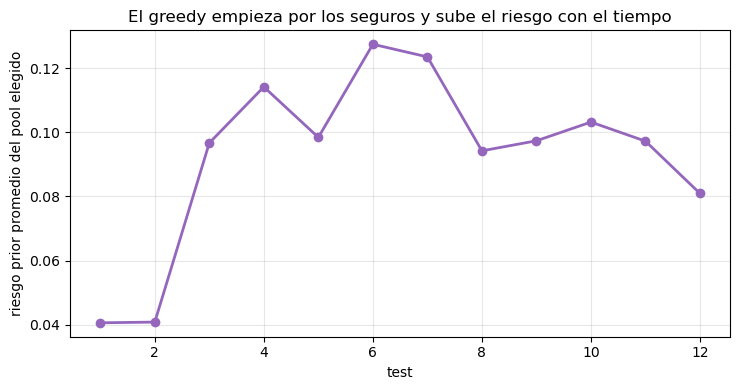

In [6]:
mean_p = [np.mean([p[i] for i in s['pool']]) for s in steps]
bs = [s['b'] for s in steps]
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(bs, mean_p, 'o-', color='tab:purple', lw=2)
ax.set_xlabel('test'); ax.set_ylabel('riesgo prior promedio del pool elegido')
ax.set_title('El greedy empieza por los seguros y sube el riesgo con el tiempo')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. El patrón que emerge

Tres regularidades, todas consecuencia de maximizar $P(r{=}0)\cdot\sum u$ paso a
paso. El greedy prioriza a la gente de bajo riesgo y alta utilidad, porque son los
que más suben el producto. Limpia en oleadas, de lo seguro a lo arriesgado, con
rendimiento decreciente. Y es miope: optimiza la cosecha inmediata, sin reservar
tests para extraer información que ayudaría después. Esa miopía es exactamente la
fuente del hueco con el óptimo.

## 7. Escalabilidad: corre a n grande, pero certificar su calidad es otra cosa

El greedy de arriba corre igual a n=50. Lo que cambia con la escala no es correrlo,
sino saber qué tan bueno es, porque el óptimo contra el que compararlo se vuelve
incomputable. Dos hechos medidos en este proyecto:

El greedy escala. La variante secuencial o gibbs corre a n=50 en ~4 s; la variante
counting (posterior exacto por $2^n$) muere ya en n=25 (6 s) y es imposible en
n=50. Las tres eligen el pool igual; solo cambia el motor del posterior.

El óptimo no escala. El DP exacto pasa de 0.7 s por instancia en n=6 a ~194 s en
n=8, y es imposible mucho antes de n=50. Y el hueco de optimalidad del greedy, en
el rango medible, no se aplana: ~2.7% (n=4), ~4.4% (n=6), ~5.5% (n=8). Por eso
extrapolar no basta: para certificar la calidad a n=50 hace falta una cota superior
computable del óptimo (relajación de información), no solo extrapolación.

In [7]:
# Cuál variante del greedy usar según n (resumen operativo)
import pandas as pd
tabla = pd.DataFrame([
    ['secuencial', 'Poisson-Binomial (independencia)', 'cualquier n', 'rápida, posterior aproximado'],
    ['counting',   'enumeración exacta 2^n',           'n <= ~20',    'exacta pero no escala'],
    ['gibbs',      'MCMC por componentes',             'n ~ 50',      'escala y es exacta en componentes chicas'],
], columns=['greedy', 'motor del posterior', 'rango', 'nota'])
print(tabla.to_string(index=False))

    greedy              motor del posterior       rango                                     nota
secuencial Poisson-Binomial (independencia) cualquier n             rápida, posterior aproximado
  counting           enumeración exacta 2^n    n <= ~20                    exacta pero no escala
     gibbs             MCMC por componentes      n ~ 50 escala y es exacta en componentes chicas


## Qué sigue

Para responderle a Francisco "¿qué tan bueno es a escala?" con rigor, el siguiente
paso es la cota superior por relajación de información: un valor $U^+ \ge U^D_A$
computable a n=50, de modo que $(U^+ - \text{greedy})/U^+$ certifique el hueco sin
calcular el óptimo. El detalle de escalabilidad e inferencia está en
`escalabilidad_e_inferencia.md`; el descubrimiento del horizonte, en
`notebook_descubrimiento.ipynb`.